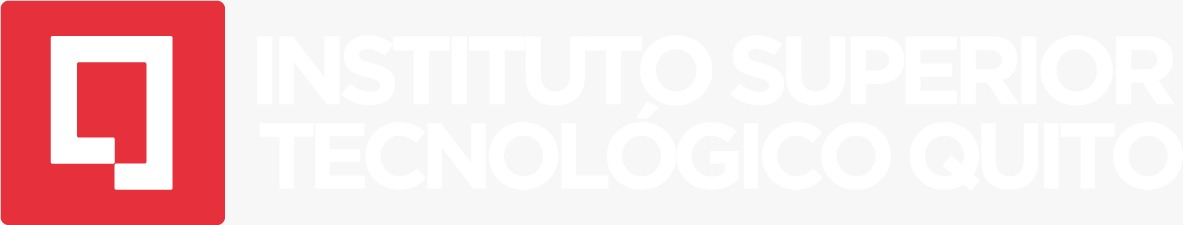

<br>

<div align="center">

## TERCER MODULO - Ficheros

</div>


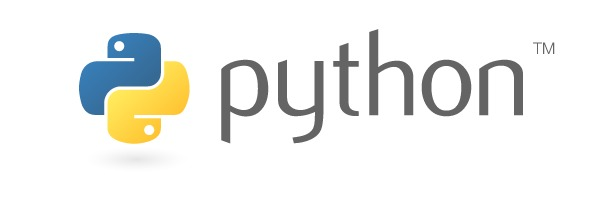
*Carlos Alberto Pucha*


# Acceso a ficheros

## Ficheros

* *File* es un tipo de objeto predefinido en Python (*built-in*).
* Permite acceder a ficheros desde programas Python.
* Los ficheros son de un tipo especial:
    * Son *built-in*, pero no son ni *números*, ni *secuencias*, ni *mappings*. Tampoco responden a operadores en expresiones.
* La función *open* permite crear objetos de tipo fichero.

Formato general para abrir un fichero:

```
afile = open(filename, mode)
```

* *mode* es opcional. Por defecto, los ficheros se abren en modo lectura.
* Los datos leidos de un fichero siempre se obtienen en formato *string*. Lo mismo ocurre con escritura.
* Los ficheros se deben cerrar invocando *close* (liberación de recursos).

In [10]:
# Lectura desde fichero usando método 'read'. Devuelve todo el contenido del fichero.
mi_fichero = open('res/multiple_lines.txt')
print(mi_fichero.read())
mi_fichero.close()

Este fichero
contiene tres
lineas de texto.



In [11]:
# Lectura linea a linea a través del bucle 'for'.
mi_fichero = open('res/multiple_lines.txt')
for linea in mi_fichero:
    print(f"{linea}")
mi_fichero.close()

Este fichero

contiene tres

lineas de texto.



In [12]:
# leer de un archivo a una lista.
mi_fichero = open('res/multiple_lines.txt')
lineas = mi_fichero.readlines()
mi_fichero.close()

print(lineas)

['Este fichero\n', 'contiene tres\n', 'lineas de texto.\n']


- Resolución de paths independiente de plataforma

In [13]:
import os
ruta = os.path.join("res", "multiple_lines.txt")
print(ruta)

res\multiple_lines.txt


In [14]:
dataset_file_path = ["res","multiple_lines.txt"]
ruta = os.path.join(*dataset_file_path)
print(ruta)

res\multiple_lines.txt


* *close* autómatico con sentencia *with.* Esta es la forma habitual de leer de fichero en Python, context manager

In [15]:
with open(ruta) as mi_fichero:
    for linea in mi_fichero:
        print(linea, end= '')

Este fichero
contiene tres
lineas de texto.


* Se puede abrir varios ficheros en un mismo *with*.

In [16]:
#abrir varios ficheros en el mismo with
ruta1 = os.path.join("res", "one_line.txt")
ruta2 = os.path.join("res", "multiple_lines.txt")
with open(ruta1) as fichero1, open(ruta2) as fichero2:
    print(fichero1.readlines())
    print(fichero2.readlines())

['Hola mundo desde un fichero aqui estamos en machine.']
['Este fichero\n', 'contiene tres\n', 'lineas de texto.\n']


## Modos de acceso

* Al crear un objeto de tipo *File* se puede espeficiar el modo de acceso (lectura/escritura).

| Modo Acceso | Descripción |
|:---------|:-----|
| r | Solo Lectura |
| w | Solo Escritura (Borra si el archivo ya existe) |
| x | Solo Escritura (Falla si el archivo ya existe) |
| a | Crea Fichero (Si existe lo abre y se añade al final) |
| r+ | Lectura y Escritura |
| b | Se puede añadir a otros modos para acceso binario
| t | Acceso para archivos de texto (default) |

## Acceso para escritura

In [17]:
def crear_lista(tamanyo):
    lista = []
    for i in range(tamanyo):
        lista.append(str(i) + '\n')
    return lista

ruta = os.path.join("res", "a_dummy.txt")
with open(ruta, 'wt') as fichero:
    fichero.write('Cabecera del ciclo del for en el ejemplo\n')
    lista = crear_lista(10)
    fichero.writelines(lista)
    print("archivo creado")

archivo creado


#### Buffering

* Por defecto, el texto que transfieres desde tu programa a un fichero no se guarda en disco inmediatamente. Se almacena en un buffer.
* Acciones como cerrar un fichero o invocar el método **flush** fuerzan que se transfiera el contenido del buffer a disco.

In [18]:
import os

ruta = os.path.join("res", "FicheroParaEscritura.txt")
fichero_write = open(ruta, 'w')
fichero_write.write('foter')

fichero_read = open(ruta, "r")
print(fichero_read.readlines())

fichero_write.flush()

print(fichero_read.readlines())

fichero_write.close()
fichero_read.close()

[]
['foter']


## Archivos CSV

* Python permite leer datos de ficheros CSV y también escribir ficheros en este formato.
* Popular formato en ciencia de datos.

In [19]:
# tabla_operaciones.csv contiene valores separados por comas
import csv
ruta = os.path.join("res", "tabla_operaciones.csv")

with open(ruta) as fichero:
    data_reader = csv.reader(fichero, delimiter=',')
    for linea in data_reader:
        print(linea[0] + '  ----  ' + linea[1])

Operacion  ----  Descripcion
a + b  ----  suma a y b
a - b  ----  resta a menos b
a / b  ----  a dividido
a // b  ----  a dividido entre b (quitando decimales)
a % b  ----  devuelve el resto de la divisiÃ³n a/b (modulus)
a * b  ----  a multiplicado por b
a ** b  ----  a elevado a b


In [20]:
ruta = os.path.join("res", "tabla_operaciones.csv")
f = open(ruta)
data_reader = csv.reader(f, delimiter = ',')

ruta_o = os.path.join("res", "4_tabla_operaciones.csv")
with open(ruta_o, 'w') as f2:
    csv_writer = csv.writer(f2, delimiter = '|')
    for line in data_reader:
        print(line)
        csv_writer.writerow(line)
        
f.close()

['Operacion', 'Descripcion']
['a + b', 'suma a y b']
['a - b', 'resta a menos b']
['a / b', 'a dividido']
['a // b', 'a dividido entre b (quitando decimales)']
['a % b', 'devuelve el resto de la divisiÃ³n a/b (modulus)']
['a * b', 'a multiplicado por b']
['a ** b', 'a elevado a b']


# Docstrings

* Python permite adjuntar documentación a los objetos e inspeccionarla a través de la línea de comandos o durante la ejecución del programa.
* Los docstrings se almacenan en el atributo *\_\_doc\_\_* de cada objeto.
* El valor de dicho atributo se puede mostrar por medio de la función *help*.

In [21]:
help(open)

Help on function open in module io:

open(file, mode='r', buffering=-1, encoding=None, errors=None, newline=None, closefd=True, opener=None)
    Open file and return a stream.  Raise OSError upon failure.
    
    file is either a text or byte string giving the name (and the path
    if the file isn't in the current working directory) of the file to
    be opened or an integer file descriptor of the file to be
    wrapped. (If a file descriptor is given, it is closed when the
    returned I/O object is closed, unless closefd is set to False.)
    
    mode is an optional string that specifies the mode in which the file
    is opened. It defaults to 'r' which means open for reading in text
    mode.  Other common values are 'w' for writing (truncating the file if
    it already exists), 'x' for creating and writing to a new file, and
    'a' for appending (which on some Unix systems, means that all writes
    append to the end of the file regardless of the current seek position).
    In

* No es necesario editar este atributo directamente.
* Para asociar un docstring a un objeto basta con escribir el texto (entre triples comillas) al principio de los modulos, funciones o clases, antes del codigo ejecutable.

In [22]:
def funcion_de_prueba():
    """Esta es la documentación de la función de prueba"""
    pass

help(funcion_de_prueba)

Help on function funcion_de_prueba in module __main__:

funcion_de_prueba()
    Esta es la documentación de la función de prueba



* Accediendo al atributo *\_\_doc\_\_* sólo se obtiene el docstring.

In [23]:
print(funcion_de_prueba.__doc__)

Esta es la documentación de la función de prueba


Como se puede observar, *help* añade información adicional. Por ejemplo, para entidades más grandes, *help* muestra el docstring dividido en secciones.

In [24]:
import sys
help(sys)

Help on built-in module sys:

NAME
    sys

MODULE REFERENCE
    https://docs.python.org/3.11/library/sys.html
    
    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    This module provides access to some objects used or maintained by the
    interpreter and to functions that interact strongly with the interpreter.
    
    Dynamic objects:
    
    argv -- command line arguments; argv[0] is the script pathname if known
    path -- module search path; path[0] is the script directory, else ''
    modules -- dictionary of loaded modules
    
    displayhook -- called to show results in an interactive session
    excepthook -- called to handle any uncaught exception other than SystemExit
      To customize pri

Los docstrings que ocupan más de una línea suelen tener estas partes:

* Resumen en la primera línea.
* Línea en blanco.
* Descripción detallada.
* Otra línea en blanco antes del código.

In [25]:
def funcion_de_prueba2():
    """Esta es la línea para el resumen.
    
    Este es el párrafo donde se puede escribir una descripción más
    detallada de la función. Observa que el resumen y la descripción
    detallada van separados por una línea en blanco. También hay
    otra línea en blanco antes de empezar el código.
    """
    
    pass

help(funcion_de_prueba2)

Help on function funcion_de_prueba2 in module __main__:

funcion_de_prueba2()
    Esta es la línea para el resumen.
    
    Este es el párrafo donde se puede escribir una descripción más
    detallada de la función. Observa que el resumen y la descripción
    detallada van separados por una línea en blanco. También hay
    otra línea en blanco antes de empezar el código.



Algunos comentarios adicionales:

* Comentarios con '#' suelen asociarse a expresiones sencillas, instrucciones individuales o pequeños bloques de código.
* Los docstrings son más apropiados para construcciones de más alto nivel: funciones, clases y módulos.

## Sphinx

* Herramienta de documentación.
* Especialmente útil para sistemas grandes.
* Da soporte a una gran variedad de formatos de salida: HTML, LaTeX, ePub, ...

Web de [Sphinx](https://www.sphinx-doc.org/).

[Proyectos](https://www.sphinx-doc.org/en/master/examples.html) que usan Sphinx.

## Estilo

* Es importante que los docstrings sean consistentes.
* El equipo de desarrollo debe acordar un formato y seguirlo rigurosamente.

#### Google Python Style Guide

Google define la siguiente [guía de estilo](https://github.com/google/styleguide/blob/gh-pages/pyguide.md#38-comments-and-docstrings).

Contiene reglas para los docstrings de:

* Módulos.
* Métodos y funciones.
* Clases.

## Ejercicios

1. Escribe una función que reciba una ruta de un fichero de texto y una cadena de caracteres a buscar y determine si la cadena aparece en el fichero.





In [17]:
def buscar_cadena_en_fichero(cadena, ruta_fichero):
    try:
        with open(ruta_fichero, 'r', encoding='utf-8') as archivo:
            contenido = archivo.read().lower()
            if cadena.lower() in contenido:
                return True
            else:
                return False
    except FileNotFoundError:
        print("Error: el archivo no existe.")
        return False




In [18]:
resultado = buscar_cadena_en_fichero("res",
    "C:/Users/karlo/Desktop/IntroduccionPython/a_dummy.txt")
print(resultado)


Error: el archivo no existe.
False


In [23]:
resultado = archivo_existe("res/a_dummy.txt")
print("Archivo encontrado exitosamente.")
print(resultado)



Archivo encontrado exitosamente.
True


In [20]:
with open("res/a_dummy.txt", "r", encoding="utf-8") as f:
    print(repr(f.read()))

print(buscar_cadena_en_fichero("cabecera", "res/a_dummy.txt"))
print(buscar_cadena_en_fichero("5", "res/a_dummy.txt"))
print(buscar_cadena_en_fichero("python", "res/a_dummy.txt"))




'Cabecera del ciclo del for en el ejemplo\n0\n1\n2\n3\n4\n5\n6\n7\n8\n9\n'
True
True
False


2. Escribe una función que reciba una lista, una ruta destino y un número *n*. La función debe crear un fichero en la ruta especificada. El contenido del fichero serán los primeros *n* elementos de la lista. La función debe controlar de manera apropiada los posibles valores de *n* que estén fuera de rango.

In [29]:
def guardar_primeros_n(lista, ruta_destino, n):
    # Verificar que n sea un entero
    if not isinstance(n, int):
        print("Error: n debe ser un número entero.")
        return False

    # Verificar rango de n
    if n < 0 or n > len(lista):
        print("Error: n está fuera del rango permitido.")
        return False

    try:
        with open(ruta_destino, 'w', encoding='utf-8') as archivo:
            for i in range(n):
                archivo.write(str(lista[i]) + "\n")
        # Leer y mostrar el contenido del archivo
        print("Contenido de salida.txt:")
        with open(ruta_destino, 'r', encoding='utf-8') as archivo:
            print(archivo.read())
                
        return True
    except Exception as e:
        print("Ocurrió un error al crear el archivo:", e)
        return False


In [30]:
datos = [10, 20, 30, 40, 50]
resultado = guardar_primeros_n(datos, "res/salida.txt", 3)
print(resultado)


Contenido de salida.txt:
10
20
30

True


In [31]:
guardar_primeros_n(datos, "res/salida.txt", 10)

Error: n está fuera del rango permitido.


False

In [32]:
guardar_primeros_n(datos, "res/salida.txt", -2)


Error: n está fuera del rango permitido.


False

3. Escribe una función que reciba una ruta de un fichero de texto devuelva un diccionario con la frecuencia de aparición de cada palabra. Ejemplo: un fichero que contenga la frase 'es mejor que venga que que no venga' devolverá el siguiente diccionario: {'es' : 1, 'mejor' : 1, 'que' : 3, 'venga' : 2, 'no' : 1}. Para dividir un string en palabras puedes hacer uso del método *split*.

In [33]:
def frecuencia_palabras(ruta_fichero):
    try:
        with open(ruta_fichero, 'r', encoding='utf-8') as archivo:
            texto = archivo.read()

        palabras = texto.split()
        frecuencias = {}

        for palabra in palabras:
            if palabra in frecuencias:
                frecuencias[palabra] += 1
            else:
                frecuencias[palabra] = 1

        return frecuencias

    except FileNotFoundError:
        print("Error: el archivo no existe.")
        return {}
    except Exception as e:
        print("Ocurrió un error:", e)
        return {}


In [34]:
resultado = frecuencia_palabras("res/diccio.txt")
print(resultado)


{'aprender': 1, 'python': 3, 'es': 2, 'importante': 1, 'porque': 1, 'facil': 1, 'de': 2, 'usar': 1, 'y': 2, 'permite': 1, 'resolver': 1, 'problemas': 1, 'forma': 1, 'rapida': 1, 'eficiente': 1}


https://github.com/AnbuDigital-Ec/introduccionpythonnocturno/blob/main/ficheros.ipynb